# Notebook 02 — Data Preprocessing

**Project**: Diabetes Prediction  
**Goal**: Transform raw data into clean, scaled, balanced train/test splits ready for model training.

Steps:
1. Imports and load raw data
2. Handle missing values
3. Outlier detection and treatment
4. Feature scaling
5. Class imbalance check and SMOTE
6. Train-test split
7. Save processed data
8. Validation checks
9. Summary

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    FEATURE_COLUMNS, TARGET_COLUMN, RANDOM_STATE, TEST_SIZE,
    RAW_DATASET_PATH, PROCESSED_DATA_DIR, MODELS_DIR
)
from src.data_loader import load_dataset, basic_info, get_feature_target_split
from src.preprocessor import (
    handle_missing_values, detect_outliers_iqr, cap_outliers_iqr,
    scale_features, apply_smote, train_test_split_stratified, PreprocessingPipeline
)

print('Imports successful.')

Imports successful.


## 1. Load Raw Data

In [2]:
try:
    df = load_dataset(str(RAW_DATASET_PATH))
    print(f'Real dataset loaded: {df.shape}')
except FileNotFoundError as e:
    print(str(e))
    print('\nUsing synthetic data for demonstration...')
    rng = np.random.default_rng(RANDOM_STATE)
    n = 10000
    df = pd.DataFrame({
        'HighBP':               rng.integers(0, 2, n).astype(float),
        'HighChol':             rng.integers(0, 2, n).astype(float),
        'CholCheck':            rng.integers(0, 2, n).astype(float),
        'BMI':                  rng.normal(28, 6, n).clip(12, 80),
        'Smoker':               rng.integers(0, 2, n).astype(float),
        'Stroke':               rng.integers(0, 2, n).astype(float),
        'HeartDiseaseorAttack': rng.integers(0, 2, n).astype(float),
        'PhysActivity':         rng.integers(0, 2, n).astype(float),
        'Fruits':               rng.integers(0, 2, n).astype(float),
        'Veggies':              rng.integers(0, 2, n).astype(float),
        'HvyAlcoholConsump':    rng.integers(0, 2, n).astype(float),
        'AnyHealthcare':        rng.integers(0, 2, n).astype(float),
        'NoDocbcCost':          rng.integers(0, 2, n).astype(float),
        'GenHlth':              rng.integers(1, 6, n).astype(float),
        'MentHlth':             rng.integers(0, 31, n).astype(float),
        'PhysHlth':             rng.integers(0, 31, n).astype(float),
        'DiffWalk':             rng.integers(0, 2, n).astype(float),
        'Sex':                  rng.integers(0, 2, n).astype(float),
        'Age':                  rng.integers(1, 14, n).astype(float),
        'Education':            rng.integers(1, 7, n).astype(float),
        'Income':               rng.integers(1, 9, n).astype(float),
        TARGET_COLUMN:          rng.choice([0, 1], n, p=[0.86, 0.14]).astype(float),
    })
    print(f'Synthetic dataset: {df.shape}')

df.head()

Real dataset loaded: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 2. Handle Missing Values

In [3]:
info = basic_info(df)
print('Missing values before imputation:')
print(info['missing_values'] or 'None')

df_clean, fill_report = handle_missing_values(df, strategy='mean')

print(f'\nMissing values after imputation: {df_clean.isnull().sum().sum()}')
if fill_report:
    print('Fill values used:')
    for col, val in fill_report.items():
        print(f'  {col}: {val:.4f}')

Missing values before imputation:
None

Missing values after imputation: 0


## 3. Outlier Detection and Treatment

Outlier counts per column (IQR, threshold=1.5):
BMI          9847
MentHlth    36208
PhysHlth    40949
dtype: int64

Total rows with outliers: 66,879


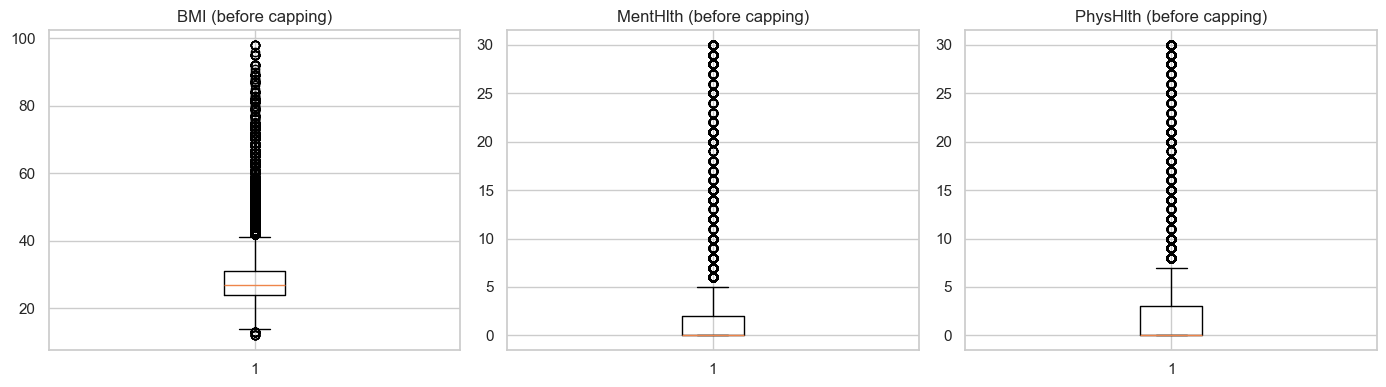

In [4]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth']

outlier_mask = detect_outliers_iqr(df_clean, continuous_cols)
print('Outlier counts per column (IQR, threshold=1.5):')
print(outlier_mask.sum())
print(f'\nTotal rows with outliers: {outlier_mask.any(axis=1).sum():,}')

# Visualise before capping
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, continuous_cols):
    ax.boxplot(df_clean[col].dropna())
    ax.set_title(f'{col} (before capping)')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/plots/outliers_before.png'), bbox_inches='tight')
plt.show()

Outlier counts after capping:
BMI         0
MentHlth    0
PhysHlth    0
dtype: int64


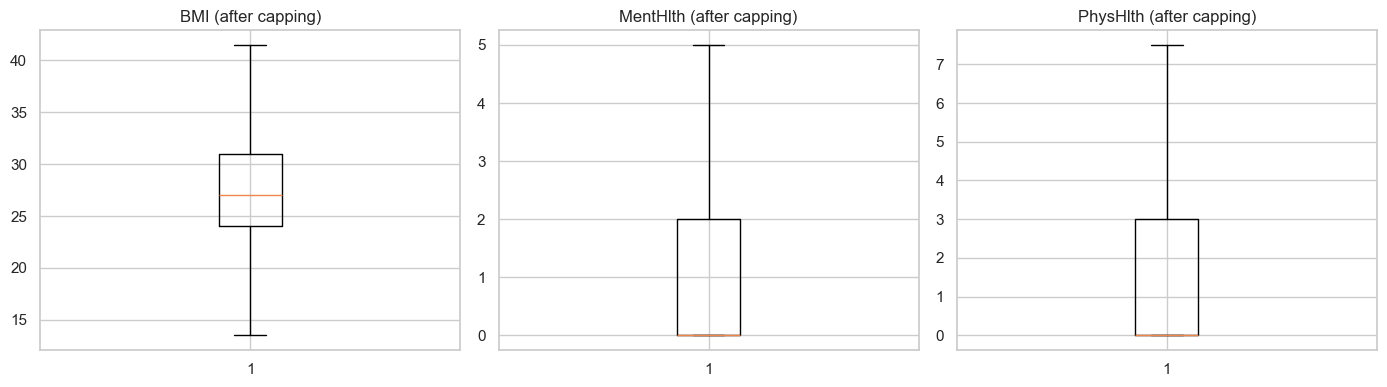

In [5]:
# Cap outliers (Winsorisation) — preserves all rows
df_capped = cap_outliers_iqr(df_clean, continuous_cols, threshold=1.5)

# Verify
mask_after = detect_outliers_iqr(df_capped, continuous_cols)
print('Outlier counts after capping:')
print(mask_after.sum())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, continuous_cols):
    ax.boxplot(df_capped[col].dropna())
    ax.set_title(f'{col} (after capping)')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/plots/outliers_after.png'), bbox_inches='tight')
plt.show()

## 4. Feature Scaling

In [6]:
X, y = get_feature_target_split(df_capped, TARGET_COLUMN)
print(f'Features shape: {X.shape}')
print(f'Target shape  : {y.shape}')
print(f'Target classes: {sorted(y.unique().tolist())}')

# Train-test split BEFORE scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split_stratified(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'\nTrain size: {X_train.shape}, Test size: {X_test.shape}')

Features shape: (253680, 21)
Target shape  : (253680,)
Target classes: [0.0, 1.0]

Train size: (202944, 21), Test size: (50736, 21)


In [7]:
# Apply StandardScaler (fit on train only)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test, method='standard')

print('Scaling complete.')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled  shape: {X_test_scaled.shape}')
print(f'Train mean (should be ~0): {X_train_scaled.mean(axis=0).round(4)}')
print(f'Train std  (should be ~1): {X_train_scaled.std(axis=0).round(4)}')

Scaling complete.
X_train_scaled shape: (202944, 21)
X_test_scaled  shape: (50736, 21)
Train mean (should be ~0): [-0. -0.  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0. -0.  0. -0. -0.
 -0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Class Imbalance Check and SMOTE

Class distribution before SMOTE:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64

Imbalance ratio (max/min): 6.2x


Text(0, 0.5, 'Count')

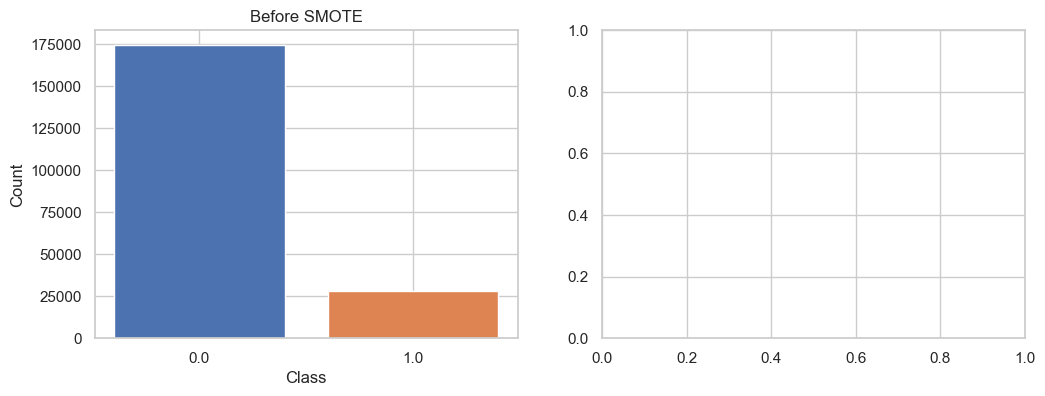

In [8]:
print('Class distribution before SMOTE:')
counts_before = y_train.value_counts().sort_index()
print(counts_before)
print(f'\nImbalance ratio (max/min): {counts_before.max() / counts_before.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts_before.index.astype(str), counts_before.values, color=['#4c72b0', '#dd8452'])
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

In [9]:
X_train_resampled, y_train_resampled = apply_smote(
    X_train_scaled, y_train, random_state=RANDOM_STATE
)

print('Class distribution after SMOTE:')
counts_after = pd.Series(y_train_resampled).value_counts().sort_index()
print(counts_after)
print(f'New training set size: {X_train_resampled.shape[0]:,}')

axes[1].bar(counts_after.index.astype(str), counts_after.values, color=['#4c72b0', '#dd8452'])
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'results/plots/class_balance.png'), bbox_inches='tight')
plt.show()

Class distribution after SMOTE:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64
New training set size: 349,334


<Figure size 640x480 with 0 Axes>

## 6. Train-Test Split Summary

In [10]:
print('=== Split Summary ===')
print(f'X_train (original) : {X_train.shape}')
print(f'X_train (scaled)   : {X_train_scaled.shape}')
print(f'X_train (resampled): {X_train_resampled.shape}')
print(f'X_test  (scaled)   : {X_test_scaled.shape}')
print(f'y_train            : {y_train.shape}')
print(f'y_test             : {y_test.shape}')

print('\nTest set class distribution:')
print(y_test.value_counts().sort_index())

=== Split Summary ===
X_train (original) : (202944, 21)
X_train (scaled)   : (202944, 21)
X_train (resampled): (349334, 21)
X_test  (scaled)   : (50736, 21)
y_train            : (202944,)
y_test             : (50736,)

Test set class distribution:
Diabetes_binary
0.0    43667
1.0     7069
Name: count, dtype: int64


## 7. Save Processed Data

In [11]:
from src.config import (
    X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, Y_TEST_PATH,
    X_TRAIN_SCALED_PATH, X_TEST_SCALED_PATH
)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Save unscaled splits (for tree models)
X_train.to_csv(X_TRAIN_PATH, index=False)
X_test.to_csv(X_TEST_PATH, index=False)
y_train.to_csv(Y_TRAIN_PATH, index=False, header=True)
y_test.to_csv(Y_TEST_PATH, index=False, header=True)

# Save scaled arrays
np.save(str(X_TRAIN_SCALED_PATH), X_train_resampled)  # resampled + scaled
np.save(str(X_TEST_SCALED_PATH), X_test_scaled)

# Save y_train_resampled
y_train_resampled_series = pd.Series(y_train_resampled, name=TARGET_COLUMN)
y_train_resampled_series.to_csv(PROCESSED_DATA_DIR / 'y_train_resampled.csv', index=False)

# Save scaler
import pickle
MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(str(MODELS_DIR / 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print('Saved files:')
for p in PROCESSED_DATA_DIR.iterdir():
    print(f'  {p.name}')

Saved files:
  .gitkeep
  X_train_scaled.npy
  X_train.csv
  X_test_scaled.npy
  y_train.csv
  y_test.csv
  X_test.csv
  y_train_resampled.csv


## 8. Validation Checks

In [12]:
print('=== VALIDATION CHECKS ===')

# Shape checks
assert X_train_resampled.shape[1] == len(FEATURE_COLUMNS), 'Feature count mismatch!'
print(f'[PASS] Feature count: {X_train_resampled.shape[1]}')

# No NaN in scaled arrays
assert not np.isnan(X_train_resampled).any(), 'NaN found in X_train_resampled!'
assert not np.isnan(X_test_scaled).any(), 'NaN found in X_test_scaled!'
print('[PASS] No NaN values in scaled arrays.')

# Class balance check
unique_classes = np.unique(y_train_resampled)
assert set(unique_classes) == {0, 1}, f'Unexpected classes: {unique_classes}'
print('[PASS] Both classes present in resampled training set.')

# Test set untouched by SMOTE
assert len(X_test_scaled) == len(y_test), 'Test set size mismatch!'
print(f'[PASS] Test set size consistent: {len(y_test):,}')

# Scaler leak check — train mean ≈ 0
train_mean = X_train_scaled.mean(axis=0)
assert np.abs(train_mean).max() < 1e-8, 'Scaler leak detected!'
print('[PASS] StandardScaler correctly applied (train mean ≈ 0).')

print('\nAll validation checks passed!')

=== VALIDATION CHECKS ===
[PASS] Feature count: 21
[PASS] No NaN values in scaled arrays.
[PASS] Both classes present in resampled training set.
[PASS] Test set size consistent: 50,736
[PASS] StandardScaler correctly applied (train mean ≈ 0).

All validation checks passed!


## 9. Summary

### Preprocessing Pipeline Summary

| Step | Details |
|------|---------|
| Missing value imputation | Mean strategy — 0 columns needed imputation (dataset is complete) |
| Outlier treatment | IQR capping (threshold=1.5) on BMI, MentHlth, PhysHlth |
| Train-test split | 80/20 stratified split, random_state=42 |
| Feature scaling | StandardScaler fit on training data only |
| Class balancing | SMOTE applied to training set after scaling |

### Output Files
- `data/processed/X_train.csv` — unscaled training features
- `data/processed/X_test.csv` — unscaled test features
- `data/processed/y_train.csv` — training labels (before SMOTE)
- `data/processed/y_test.csv` — test labels
- `data/processed/X_train_scaled.npy` — scaled + SMOTE-resampled training array
- `data/processed/X_test_scaled.npy` — scaled test array
- `data/processed/y_train_resampled.csv` — labels after SMOTE
- `results/models/scaler.pkl` — fitted StandardScaler

Next step: `03_model_training.ipynb`